In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../modules/') 
from config import hsd, num_threshold, num_maximum
from rule import rule_matrix
from tensor_v2 import *

order = 2


# SVD did not converge
❌ the singular values are not diverging
❌ RAM doesn't seem to max-out
❌ no np.nan, np.inf or None values
✅ the function zero_rounding seemed to help, but the maximum error seems to increase with this method
❔  another possibility could be to switch to scipy.linalg.svd, where you can use different lapack drivers

# other solutions
- use a try statement, and if it does not converge, then just skip this bond

# numerical stability
- check how well the error growth is suppressed by higher values of num_threshold
- implement the check_RAM function

In [7]:
rule = 150

error_multi = []
bonds_multi = []

ms = 10


for sites in range(3,ms):
    R = rule_matrix(rule,order)
    tensors = operator_to_mpo(R)

    network = create_network(tensors,sites)

    operator = np.rint(mpo_to_operator(network))

    bonds = []
    error = []

    network = optimize_bonds(network)         
    bonds.append(bonds_of_mpo(network))
    error.append(np.max(np.abs(mpo_to_operator(network)-operator)))

    step = network.copy()
    operator_step = operator.copy()
    for _ in range(14):
        network = optimize_bonds(product(network,step))    
        operator = np.rint(operator@operator_step)
        bonds.append(bonds_of_mpo(network))
        error.append(np.max(np.abs(mpo_to_operator(network)-operator)))
    error_multi.append(error)
    bonds_multi.append(bonds)
print("🤖 bleep bloop...")

🤖 bleep bloop...


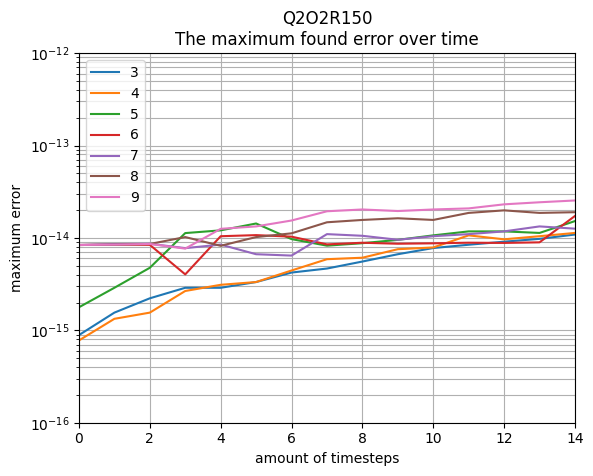

In [18]:
for i,error in enumerate(error_multi):
    plt.plot(error,label=f'{3+i}')
plt.xlabel('amount of timesteps')
plt.ylabel('maximum error')
plt.title(f"Q{hsd}O{order}R{rule}\nThe maximum found error over time")
plt.xlim(0,len(error_multi[0])-1)
plt.legend()
plt.grid(which='both')
plt.ylim(1e-16,1e-12)
plt.yscale('log')
plt.savefig(f'./../../data/error_analysis/Q{hsd}O{order}R{rule}')
plt.show()


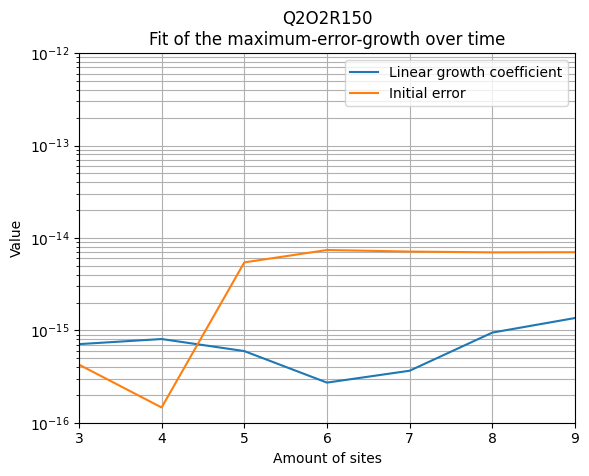

In [19]:
fit = []
for error in error_multi:
    fit.append(np.polyfit(list(range(len(error))),error,deg=1))
plt.plot(list(range(3,ms)),np.array(fit).T[0],label='Linear growth coefficient')
plt.plot(list(range(3,ms)),np.array(fit).T[1],label='Initial error')
plt.xlabel('Amount of sites')
plt.ylabel('Value')
plt.title(f"Q{hsd}O{order}R{rule}\nFit of the maximum-error-growth over time")
plt.legend()
plt.xlim(3,ms-1)
plt.grid(which='both')
plt.ylim(1e-16,1e-12)
plt.yscale('log')
plt.savefig(f'./../../data/error_analysis/Q{hsd}O{order}R{rule}_fit')
plt.show()